In [ ]:
#Run those codes in shell
# The raw data were SRR13451173 and SRR13451172
#1。 basecall fastq reads from raw fast5 files, and transform to fasta. Run for both mod and unmod groups.
guppy_basecaller -i fast5_pass_s -s out -c ont-guppy-cpu/data/rna_r9.4.1_70bps_fast.cfg -r  --num_callers 16 --cpu_threads_per_caller 16;
cat pass/*.fastq >>all.fastq
sed 's/U/T/g' all.fastq >all.T.fastq
awk '{if((NR+3)%4==0)printf ">"$1;if((NR+2)%4==0)print "\n"$1}'  all.T.fastq > all.fa
sed 's/>@/>/g' all.fa >all.fasta
#2、blast against 9 sgRNAs
blastn -query Mod.all.fasta -db ../sgRNAs.fa -out Mod_all.blast -outfmt "7 qseqid qlen sseqid slen length pident mismatch qstart qend sstart send evalue bitscore" -num_descriptions 1 -num_alignments 1 -num_threads 28
blastn -query Unmod.all.fasta -db ../sgRNAs.fa -out Unmod.all.blast -outfmt "7 qseqid qlen sseqid slen length pident mismatch qstart qend sstart send evalue bitscore" -num_descriptions 1 -num_alignments 1 -num_threads 28
grep -v '^#' Mod_all.blast > Mod_all.blast.csv
grep -v '^#' Unmod.all.blast > Unmod.all.blast.csv


In [ ]:
#read the blast files and extract reads aligned to sgRNA N
#分离Mod组中sgRNA N的Reads
Moddf = pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/Mod_all.blast.csv',sep='\t', names=['qseqid','qlen','sseqid','slen','length','pident','mismatch','qstart','qend','sstart','send','evalue','bitscore'])
Moddf_short=Moddf[(Moddf['sstart']<30)&(Moddf['send']>300)]
ModdfN=Moddf_short[Moddf_short['sseqid']=='N'] #304626

ModdfN.sample(n=500, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name500.txt',sep='\t',header=False, index=False) 
ModdfN.sample(n=100, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name100.txt',sep='\t',header=False, index=False) 
ModdfN.sample(n=1000, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name1000.txt',sep='\t',header=False, index=False) 
ModdfN.sample(n=10000, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name10000.txt',sep='\t',header=False, index=False) 
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Modfast5/Mod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name500.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N500.fastq")
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Modfast5/Mod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name100.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N100.fastq")
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Modfast5/Mod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name1000.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N1000.fastq")
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Modfast5/Mod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N.name10000.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N10000.fastq")

#分离unmod组中sgRNA N的Reads
Unmoddf = pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Unmodfast5/Unmod.all.blast.csv',sep='\t', names=['qseqid','qlen','sseqid','slen','length','pident','mismatch','qstart','qend','sstart','send','evalue','bitscore'])
Unmoddf_short=Unmoddf[(Unmoddf['sstart']<30)&(Unmoddf['send']>300)]
UnmoddfN=Unmoddf_short[Unmoddf_short['sseqid']=='N'] #72416

UnmoddfN.sample(n=500, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name500.txt',sep='\t',header=False, index=False) 
UnmoddfN.sample(n=100, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name100.txt',sep='\t',header=False, index=False) 
UnmoddfN.sample(n=1000, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name1000.txt',sep='\t',header=False, index=False) 
UnmoddfN.sample(n=10000, random_state=42)['qseqid'].to_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name10000.txt',sep='\t',header=False, index=False) 
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/Unmod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name500.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N500.fastq")
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/Unmod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name100.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N100.fastq")
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/Unmod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name1000.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N1000.fastq")
os.system("/data1/huangyong/tools/fastqselect.tcl -infile /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/Unmod.all.T.fastq -name /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N.name10000.txt -outfile /data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N10000.fastq")


In [ ]:
# Run those codes in shell
ref=/data1/huangyong/Project/Nanopore/SARS/N.fa
outdir=/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split
Mod_fast5=/data1/huangyong/Project/Nanopore/SARS/Modfast5/fast5_pass_s
Unmod_fast5=/data1/huangyong/Project/Nanopore/SARS/Unmodfast5/fast5_pass_s
dir_=/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split

python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Mod_N10000.fastq  -s $Mod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Modfast5/sequencing_summary.txt -d $dir_ -n Mod_N10000 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Unmod_N10000.fastq  -s $Unmod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/sequencing_summary.txt -d $dir_ -n Unmod_N10000 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m $dir_/Mod_N10000.collapsed.event -u $dir_/Unmod_N10000.collapsed.event -l 1640 -b 9 
python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m $dir_/Mod_N10000.collapsed.event.profile.vect -u $dir_/Unmod_N10000.collapsed.event.profile.vect -o N10000_scores -s mean 

python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Mod_N100.fastq  -s $Mod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Modfast5/sequencing_summary.txt -d $dir_ -n Mod_N100 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Unmod_N100.fastq  -s $Unmod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/sequencing_summary.txt -d $dir_ -n Unmod_N100 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m $dir_/Mod_N100.collapsed.event -u $dir_/Unmod_N100.collapsed.event -l 1640 -b 9 
python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m $dir_/Mod_N100.collapsed.event.profile.vect -u $dir_/Unmod_N100.collapsed.event.profile.vect -o N100_scores -s mean 

python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Mod_N1000.fastq  -s $Mod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Modfast5/sequencing_summary.txt -d $dir_ -n Mod_N1000 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Unmod_N1000.fastq  -s $Unmod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/sequencing_summary.txt -d $dir_ -n Unmod_N1000 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m $dir_/Mod_N1000.collapsed.event -u $dir_/Unmod_N1000.collapsed.event -l 1640 -b 9 
python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m $dir_/Mod_N1000.collapsed.event.profile.vect -u $dir_/Unmod_N1000.collapsed.event.profile.vect -o N1000_scores -s mean 

python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Mod_N500.fastq  -s $Mod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Modfast5/sequencing_summary.txt -d $dir_ -n Mod_N500 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/dataprocessing.py -r ${ref} -q Unmod_N500.fastq  -s $Unmod_fast5 -S /data1/huangyong/Project/Nanopore/SARS/Unmodfast5/sequencing_summary.txt -d $dir_ -n Unmod_N500 -i
python /data1/huangyong/Project/Nano_seq/nanoDISH/predictModbase_vect.py -m $dir_/Mod_N500.collapsed.event -u $dir_/Unmod_N500.collapsed.event -l 1640 -b 9 
python /data1/huangyong/Project/Nano_seq/nanoDISH/scoreIntermediate_vect.py -m $dir_/Mod_N500.collapsed.event.profile.vect -u $dir_/Unmod_N500.collapsed.event.profile.vect -o N500_scores -s mean 



In [74]:
import os
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None
from collections import Counter
import scipy.stats
from scipy.stats import spearmanr
from scipy.stats import pearsonr
from statistics import mean
from scipy import stats
import umap
from sklearn.mixture import GaussianMixture
import math
from sklearn.metrics import silhouette_score
from RNA import General,Structure, Visual
import matplotlib
%matplotlib inline
from scipy.ndimage import gaussian_filter1d

In [12]:
def CalculateSHAPEFromBitvector_mod(Modvect):
    Percentlist=[]
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    rates=NAI_one/(NAI_one+NAI_zero)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def CalculateSHAPEFromBitvector_control(Modvect,Unmodvect,alpha):
    NAI_one=np.sum(Modvect==1,axis=0)
    NAI_zero=np.sum(Modvect==0,axis=0)
    NAI_two=np.sum(Modvect==2,axis=0)
    DMSO_two=np.sum(Unmodvect==2,axis=0)
    DMSO_zero=np.sum(Unmodvect==0,axis=0)
    delta=list(map(lambda x: x[0]-x[1] if x[0]>x[1] else 0, zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    #delta=list(map(lambda x: x[0]-x[1], zip(NAI_two/(NAI_two+NAI_one+NAI_zero),DMSO_two/(DMSO_two+DMSO_zero))))
    rates=NAI_one/(NAI_one+NAI_zero)+np.multiply(delta,alpha)
    shapescore=Normal_SHAPE(rates)
    return shapescore

def Normal_SHAPE(inlist,windowsize=100,step=5): #采用icSHAPE-pipe的策略，在Windows内，top5%为1，最低5%为0
    shape=[[] for i in range(len(inlist))]
    finalshape=[0 for i in range(len(inlist))]
    start=0
    while start+windowsize< len(inlist):
        sublist=np.array(inlist[start:start+windowsize])
        s95=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 95)
        s5=stats.scoreatpercentile(sublist[~np.isnan(sublist)], 5)
        subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in sublist]
        for i in range(windowsize):
            shape[start+i].append(subshape[i])
        start+=step
    #处理最后一个window
    endsublist=np.array(inlist[start:])
    s95=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 95)
    s5=stats.scoreatpercentile(endsublist[~np.isnan(endsublist)], 5)
    subshape=[1 if i>s95 else (0 if i<s5 else (i-s5)/(s95-s5)) for i in endsublist]
    for i in range(len(endsublist)):
        shape[start+i].append(subshape[i])
    #对每个位置的值求平均
    for i in range(len(inlist)):
        finalshape[i]=mean(shape[i])
    return finalshape

def get_index(lst=None, item=''):
    return [index for (index,value) in enumerate(lst) if value == item]


def color_SHAPE(shape_list, cutoff=[0.3, 0.5, 0.7]):
    """
    shape_list              -- A list of SHAPE scores
    cutoff                  -- Cutoff of SHAPE color boundaries.
    
    Transform SHAPE values to color blocks
    """
    color_blocks=[]
    for value in shape_list:
        if value == 'NULL':
            color_blocks.append('lightgray')
        else:
            shape = float(value)
            if shape < cutoff[0]:
                color_blocks.append('black')
            elif shape < cutoff[1]:
                color_blocks.append('blue')
            elif shape < cutoff[2]:
                color_blocks.append('orange')
            else:
                color_blocks.append('red')
    
    return color_blocks
def SHAPEWindowcorrelation(shape1,shape2,windowsize):
    my_list1 = [0 if math.isnan(x) else x for x in shape1]
    my_list2 = [0 if math.isnan(x) else x for x in shape2]
    corre=[]
    start=0
    size=windowsize
    while start+size < len(my_list1):
        end=start+size
        subshape1=my_list1[start:end]
        subshape2=my_list2[start:end]
        t, p = scipy.stats.pearsonr(subshape1, subshape2)
        corre.append(round(t, 3))
        start+=1
    head=[0 for i in range(int(windowsize/2))]
    return head+corre+head

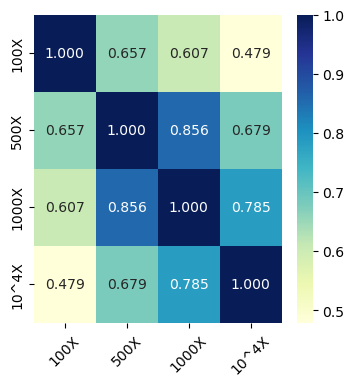

In [34]:
#compare the mean scores at 10^1~4 groups
Score100=pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/N100_scores.score',sep='\t',index_col=0)
Score500=pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/N500_scores.score',sep='\t',index_col=0)
Score1000=pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/N1000_scores.score',sep='\t',index_col=0)
Score10000=pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/N10000_scores.score',sep='\t',index_col=0)

Score100_smooth=gaussian_filter1d(Score100['score'].tolist(), sigma=5)
Score500_smooth=gaussian_filter1d(Score500['score'].tolist(), sigma=5)
Score1000_smooth=gaussian_filter1d(Score1000['score'].tolist(), sigma=5)
Score10000_smooth=gaussian_filter1d(Score10000['score'].tolist(), sigma=5)

scorelist=[Score100_smooth, Score500_smooth, Score1000_smooth,Score10000_smooth]
namelists=['100X','500X','1000X','10^4X']
n=4
pearsonr_df = General.init_pd_rect(n, n, namelists, namelists)
for i in range(n):
    for j in range(i, n):
        t, p = scipy.stats.pearsonr(scorelist[i], scorelist[j])
        pearsonr_df.iloc[i, j] = pearsonr_df.iloc[j, i] = round(t, 3)

plt.figure(figsize=(4,4))
sns.heatmap(pearsonr_df, cmap='YlGnBu', annot=True, fmt=".3f")
#plt.title("Pearson Correlation coefficient of 16S")
plt.xticks(rotation=45)
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Downsample_correlation.pdf")
#plt.close()


[(1, 8140), (0, 1607)]


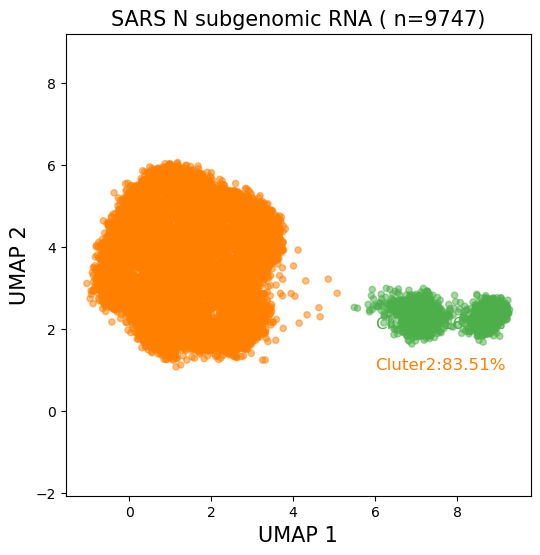

In [70]:
SARS_N_mod=pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Mod_N10000.collapsed.event.profile.vect',sep='\t',index_col=0)
SARS_N_unmod=pd.read_csv('/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/Unmod_N10000.collapsed.event.profile.vect',sep='\t',index_col=0)
SARS_N_seq=General.load_fasta('/data1/huangyong/Project/Nanopore/SARS/N.fa')

SARS_N_classdf=SARS_N_mod
UP = umap.UMAP(n_components=2)
SARS_N_UMAP = pd.DataFrame(UP.fit_transform(SARS_N_classdf),columns = ['UMAP1', 'UMAP2'])

#SARS_N_clustering =DBSCAN(eps=0.2, min_samples=2).fit(SARS_N_UMAP)
#SARS_N_clust_ids =SARS_N_clustering.labels_.tolist()
SARS_N_clustering =GaussianMixture(n_components =2,covariance_type='full',random_state=1).fit(SARS_N_UMAP)
SARS_N_clust_ids = SARS_N_clustering.predict(SARS_N_UMAP).tolist()
print(Counter(SARS_N_clust_ids).most_common(int(3)))
cluster_color = { 0: '#4daf4a', 1: '#ff7f00', 2: '#f781bf',3:'#0000FF',4:'gray',-1:'black'}

SARS_N_number_c1=SARS_N_clust_ids.count(0)/len(SARS_N_clust_ids)
SARS_N_number_c2=SARS_N_clust_ids.count(1)/len(SARS_N_clust_ids)

fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(1,1,1) 
plt.scatter(SARS_N_UMAP['UMAP1'], SARS_N_UMAP['UMAP2'], c = [cluster_color[x]  if x in [0,1] else 'gray' for x in  SARS_N_clust_ids], s = 20, alpha = 0.50 )
ax.set_xlabel('UMAP 1', fontsize = 15)
ax.set_ylabel('UMAP 2', fontsize = 15)
ax.text(6,2,'Cluter1:{:.2%}'.format(SARS_N_number_c1),c=cluster_color[0],fontsize = 12)
ax.text(6,1,'Cluter2:{:.2%}'.format(SARS_N_number_c2),c=cluster_color[1], fontsize = 12)
#ax.text(1,1.3,'Cluter3:{:.2%}'.format(TPPnoli_number_c3),c=cluster_color[2], fontsize = 12)

ax.set_title(f'SARS N subgenomic RNA ( n={len(SARS_N_clust_ids)})', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/N1000.UMAP.pdf")
#plt.close()

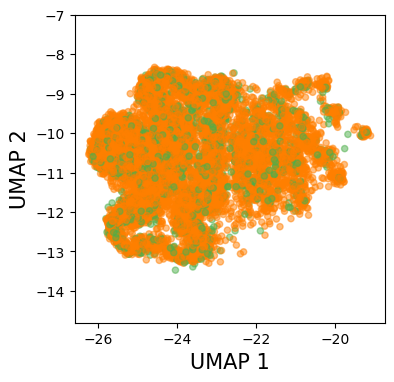

In [36]:
SARS_N_onlyModify=SARS_N_classdf.replace(2, 0)
#print(clas_onlyMiscall)
UP = umap.UMAP(n_components=2)
SARS_NModUMAP=pd.DataFrame(UP.fit_transform(SARS_N_onlyModify) ,columns = ['UMAP1', 'UMAP2'])

fig = plt.figure(figsize = (4,4))
ax = fig.add_subplot(1,1,1) 
plt.scatter(SARS_NModUMAP['UMAP1'], SARS_NModUMAP['UMAP2'],c =[cluster_color[x]  if x in [0,1] else 'gray' for x in  SARS_N_clust_ids], s = 20, alpha = 0.50)
ax.set_xlabel('UMAP 1', fontsize = 15)
ax.set_ylabel('UMAP 2', fontsize = 15)
ax.set_aspect('equal', 'box')
plt.axis('equal')
#plt.savefig("/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/N10000.UMAP.onlyModify.pdf")
#plt.close()
plt.show()

In [19]:
silhouette_score(SARS_N_UMAP, SARS_N_clust_ids)

0.6887193

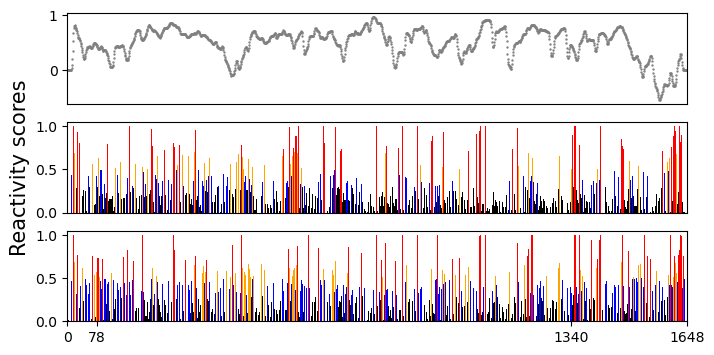

In [71]:
SARS_N_pos=[i for i in range(len(SARS_N_seq['N']))]

SARS_N_C1=SARS_N_classdf.iloc[get_index(SARS_N_clust_ids,0),:]
SARS_N_C2=SARS_N_classdf.iloc[get_index(SARS_N_clust_ids,1),:]

SARS_N_score1=CalculateSHAPEFromBitvector_control(SARS_N_C1,SARS_N_unmod,1)
SARS_N_score2=CalculateSHAPEFromBitvector_control(SARS_N_C2,SARS_N_unmod,1)

#SARS_N_score1=CalculateSHAPEFromBitvector_mod(SARS_N_C1)
#SARS_N_score2=CalculateSHAPEFromBitvector_mod(SARS_N_C2)
#SARS_N_score1_smooth=gaussian_filter1d(SARS_N_score1, sigma=2)
#SARS_N_score2_smooth=gaussian_filter1d(SARS_N_score2, sigma=2)

SARS_N_correlation=SHAPEWindowcorrelation(SARS_N_score1,SARS_N_score2,30)
SARS_Ncorrelation_smooth=gaussian_filter1d(SARS_N_correlation, sigma=2)

fig = plt.figure(figsize = (8,4))

ax = fig.add_subplot(3,1,1) 
plt.scatter(SARS_N_pos, SARS_Ncorrelation_smooth, s = 0.5,color ='gray' ,label='Cor')
plt.xticks([])
plt.xlim(0,1649)


ax = fig.add_subplot(3,1,2) 
plt.bar(SARS_N_pos, SARS_N_score1,  color =color_SHAPE(SARS_N_score1) ,label='Cluster1')
plt.ylabel("Reactivity scores",fontsize=15) 
#plt.title('SHAPE scores of the individual clusters (16S SARS_N) ',fontsize=15)

#ax.set_xticks(TPPlist, fontsize=6)
#ax.set_xticklabels(TPPseq, fontsize=6)
plt.xticks([])
#plt.legend(loc="upper right")
plt.xlim(0,1649)

plt.subplot(3, 1, 3)
plt.bar(SARS_N_pos, SARS_N_score2,  color =color_SHAPE(SARS_N_score2) ,label='Cluster2')
plt.xticks([])
#plt.legend(loc="upper right")
plt.xlim(0,1649)
plt.xticks([0,78,1340,1648])
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/SARS/Modfast5/N_split/N10000_shape scores.pdf")
#plt.close()

In [54]:
#structure compare 
# the data comes from the https://www.nature.com/articles/s41467-021-25357-1: Data7.csv
Pore_UTR_WT_rates=[0.002646,0.00237,0.003759,0,0,0.002222,0,0,0,0,0,0,0.002058,0,0,0.002183,0,0.002024,0.002028,0.002024,0.001012,0.002024,0.002028,0.006122,0.006186,0.004098,0,0.002107,0,0.00207,0,0,0.002041,0.002096,0.010707,0.004292,0.002092,0.014433,0.032587,0.002037,0.002096,0,0.004246,0,0,0,0,0,0.002053,0,0,0,0,0,0,0,0,0.00102,0,0,0,0,0,0,0,0,0.002088,0.002079,0.006757,0.012563,0.004175,0.006508,0.005241,0.004175,0.01046,0.004137,0.012371,0.014403,0.010267,0.00813,0.002037,0,0.004107,0.002041,0.002028,0.002024,0.00202,0.002024,0.002024,0,0.004073,0.004098,0.006383,0.004348,0.008403,0.00616,0.008538,0.002242,0.002155,0.004348,0.002193,0.002101,0.002128,0.002045,0,0.001092,0.002088,0.002101,0.004149,0.002037,0.002026,0.004049,0.002028,0.004065,0.008114,0.002024,0.004049,0.002049,0.00616,0.004193,0.006211,0.002053,0.002026,0.002024,0.002028,0.00308,0.00207,0.002105,0.002066,0.002051,0.004158,0.008351,0.008333,0.006198,0.008163,0.004073,0.004065,0.004107,0.006356,0.015927,0.002101,0.004098,0.008264,0.002092,0.005165,0.002053,0.008147,0.005071,0,0.002033,0.002028,0.002033,0.00102,0,0.002064,0,0.002049,0.004094,0.00409,0.002045,0.014315,0.006237,0.012245,0.002053,0,0.002041,0.002037,0.002053,0.004107,0.004115,0.00207,0.002049,0.002151,0,0.002053,0.002041,0.002033,0.002026,0.002026,0.004057,0.002037,0.002033,0.002037,0.002037,0.002037,0.002041,0.002049,0.002066,0.004357,0.008065,0.002275,0.002112,0.004141,0,0.00207,0,0.002079,0.002049,0.004065,0.00818,0.006224,0.010482,0.011521,0.006303,0.006211,0.010537,0.006316,0.00409,0,0.004065,0.004086,0.004141,0.002088,0.006231,0.002096,0.002062,0.002049,0.002045,0.002058,0.002058,0.002037,0.002058,0.006186,0.002066,0.002058,0.002062,0,0.004184,0.002064,0,0.011136,0,0,0.002041,0.00409,0.018499,0.002088,0.002092,0.004124,0.002096,0.002183,0.004082,0.004065,0.004098,0.010267,0.008214,0.00818,0.002047,0,0.002404,0.004706,0.002451,0.006881,0.002217,0,0.002183,0,0.002033,0,0.002064,0.002039,0,0.004107,0.002079,0.006237,0.002079,0.004219,0.004211,0.00432,0.006356,0.010299,0.006218,0.002092,0.006369,0.008696,0.006211,0.002075,0.002088,0,0.006912,0.002174,0.002262,0.003333,0.002123,0.002141,0.002174,0.002222,0.004353,0.002151,0.002415,0.002439,0,0,0,0,0.001326,0,0]
Pore_UTR_WT_sum_rates=[0.002871,0.002667,0.00237,0.000535,0.000836,0.001402,0.000554,0.000278,0.000861,0.000429,0,0.000527,0.001048,0.000571,0.000572,0.000831,0.000266,0.001287,0.000773,0.000772,0.000643,0.001031,0.002063,0.004421,0.005502,0.002858,0.00026,0.001865,0.000547,0.0021,0.000258,0.000644,0.00259,0.001469,0.008186,0.003826,0.003329,0.014988,0.032129,0.002457,0.000797,0.000552,0.002819,0.000262,0.001048,0.000271,0,0.000784,0.000782,0.000262,0.000775,0,0.000518,0,0,0.000627,0.000264,0.000648,0.000775,0.000257,0.000258,0.000259,0.001032,0.000516,0.00052,0.001052,0.002119,0.001847,0.005871,0.009459,0.003178,0.006045,0.005465,0.002911,0.008926,0.003152,0.009677,0.014343,0.009871,0.006203,0.001808,0.001039,0.003645,0.001554,0.00129,0.001799,0.001541,0.002055,0.001156,0.000774,0.003358,0.003645,0.00366,0.004149,0.007982,0.004689,0.006205,0.001418,0.00245,0.003558,0.001662,0.001868,0.001896,0.002075,0,0.001795,0.002121,0.001342,0.003165,0.002067,0.002315,0.003079,0.002828,0.004126,0.007066,0.002311,0.003077,0.001821,0.004946,0.002386,0.005763,0.002588,0.002053,0.002565,0.002315,0.002471,0.001312,0.001338,0.001049,0.002075,0.003945,0.006491,0.007663,0.007301,0.008024,0.003102,0.002833,0.004409,0.005353,0.014161,0.002123,0.003119,0.007982,0.002389,0.005882,0.001825,0.008137,0.004498,0.001286,0.002059,0.000771,0.001028,0.000902,0,0.001824,0.00026,0.002342,0.002591,0.004139,0.002329,0.015024,0.006861,0.012416,0.002343,0.001032,0.002841,0.001803,0.002337,0.004802,0.003649,0.002101,0.001297,0.002445,0.000527,0.002209,0.002324,0.002188,0.001924,0.002053,0.003083,0.001803,0.002318,0.002061,0.001805,0.002576,0.002063,0.001689,0.00131,0.003036,0.006594,0.002894,0.00241,0.004455,0.001555,0.00131,0.000804,0.002632,0.002337,0.004117,0.00776,0.005758,0.008201,0.008763,0.004515,0.004192,0.009425,0.005318,0.003101,0.000903,0.003343,0.004139,0.004187,0.002118,0.005522,0.002119,0.002211,0.001816,0.00181,0.001298,0.001298,0.001801,0.001817,0.005722,0.002347,0.00234,0.002088,0.001043,0.00504,0.001571,0.001663,0.008841,0.000525,0.001033,0.001807,0.003102,0.016866,0.002101,0.001318,0.002994,0.001324,0.001376,0.003099,0.003851,0.003627,0.009588,0.007139,0.007754,0.00285,0.001426,0.001684,0.002681,0.001871,0.00692,0.002515,0.001077,0.002497,0.000264,0.000515,0.001165,0.002081,0.002059,0.000775,0.002593,0.001832,0.004573,0.00183,0.002915,0.002782,0.003005,0.006519,0.007405,0.006009,0.001577,0.006262,0.006574,0.004968,0.001576,0.00223,0.001081,0.005557,0.001503,0.001709,0.002372,0.001333,0.002146,0.002712,0.001662,0.004651,0.002846,0.002732,0.001227,0.000931,0.001233,0.000656,0.000329,0.000166,0.000669,0]
 
Pore_UTR_Delt_rates=[0.010218,0.003688,0.004422,0.007518,0.001357,0.00104,0.002075,0.002619,0.001533,0.001836,0.001908,0.00189,0.001107,0.002205,0.001332,0.000985,0.00092,0.001527,0.002174,0.001221,0.00122,0.001037,0.001811,0.002545,0.00722,0.009734,0.004202,0.000762,0.003067,0.001583,0.002248,0.001675,0.00157,0.003562,0.003705,0.014625,0.008041,0.008277,0.01902,0.046024,0.004391,0.002485,0.001465,0.003351,0.001351,0.001163,0.001443,0.001133,0.00168,0.001571,0.000808,0.001185,0.000756,0.001129,0.000915,0.0011,0.000872,0.001005,0.001478,0.001024,0.001834,0.001433,0.001373,0.000796,0.001082,0.002099,0.002195,0.003517,0.003273,0.010572,0.015201,0.005203,0.010441,0.006846,0.004509,0.015568,0.005683,0.02025,0.022963,0.011426,0.012847,0.003532,0.001608,0.005288,0.002604,0.002038,0.002481,0.001871,0.00299,0.002728,0.001965,0.00614,0.006053,0.006775,0.006424,0.012814,0.008321,0.012655,0.003662,0.003998,0.005804,0.003024,0.001599,0.001835,0.003111,0.001556,0.001363,0.002497,0.002067,0.005221,0.003763,0.002978,0.007166,0.005973,0.008477,0.013778,0.004732,0.005931,0.003969,0.011649,0.005363,0.011187,0.004471,0.004724,0.004659,0.004162,0.00476,0.004562,0.002326,0.002933,0.004518,0.007102,0.010536,0.011426,0.010351,0.015397,0.008354,0.007009,0.009062,0.010944,0.023661,0.003444,0.006148,0.013054,0.00361,0.010075,0.003819,0.015723,0.00799,0.001679,0.003377,0.002386,0.001899,0.001925,0.001316,0.002546,0.001485,0.003906,0.003691,0.006617,0.003585,0.017925,0.011015,0.021397,0.004691,0.003039,0.00573,0.003928,0.003625,0.007669,0.005045,0.002771,0.001793,0.002387,0.002159,0.003343,0.002985,0.001794,0.001727,0.002255,0.003864,0.0021,0.002241,0.002266,0.002679,0.003825,0.002603,0.003169,0.002374,0.004883,0.007228,0.004167,0.003453,0.004193,0.003357,0.003203,0.001576,0.005185,0.003661,0.00366,0.009747,0.007254,0.011052,0.016431,0.008069,0.007956,0.014494,0.010822,0.005753,0.002083,0.00414,0.005026,0.00551,0.003975,0.007837,0.003259,0.003061,0.003049,0.001602,0.002493,0.001959,0.002549,0.002767,0.006414,0.003132,0.003059,0.002552,0.001222,0.007868,0.004468,0.002648,0.01791,0.001662,0.001722,0.002667,0.004776,0.022407,0.002896,0.00257,0.006482,0.002644,0.00205,0.008825,0.0083,0.006159,0.01418,0.011321,0.011899,0.0045,0.0025,0.004241,0.003928,0.003184,0.009714,0.00289,0.000911,0.004417,0.001402,0.001657,0.00214,0.002374,0.002928,0.001482,0.006198,0.003231,0.009876,0.005238,0.005897,0.007321,0.008079,0.01176,0.014763,0.011184,0.00492,0.010784,0.01121,0.008682,0.003114,0.005813,0.002423,0.008582,0.004561,0.002841,0.003573,0.003292,0.002907,0.004111,0.002259,0.006426,0.00536,0.004039,0.003932,0.001741,0.002222,0.00214,0.00143,0.001618,0]
Pore_UTR_Delt_sum_rates=[0.008105,0.003344,0.003456,0.005797,0.00078,0.001252,0.001732,0.002177,0.001303,0.001815,0.001221,0.00144,0.000682,0.001925,0.000849,0.001739,0.001171,0.001757,0.001172,0.001251,0.002062,0.00113,0.001628,0.001581,0.005581,0.008054,0.003377,0.000828,0.002674,0.001504,0.002719,0.001602,0.001418,0.002626,0.002937,0.013754,0.007165,0.006958,0.019159,0.045989,0.003888,0.001845,0.001381,0.003365,0.001309,0.001346,0.001284,0.001115,0.001426,0.001943,0.000879,0.000703,0.000661,0.001104,0.001425,0.001048,0.002406,0.001237,0.001861,0.002067,0.001368,0.001543,0.001408,0.001377,0.001194,0.00123,0.003052,0.002905,0.004266,0.007884,0.014571,0.00527,0.009822,0.00712,0.003566,0.013785,0.004928,0.02165,0.019426,0.010331,0.012812,0.003079,0.001728,0.004599,0.003715,0.002333,0.001951,0.002188,0.002991,0.001828,0.002163,0.005799,0.005095,0.005044,0.007586,0.011022,0.008716,0.009452,0.003844,0.004123,0.00684,0.003138,0.002172,0.001272,0.002368,0.001569,0.00235,0.002359,0.002111,0.005445,0.00349,0.002735,0.005572,0.005333,0.008429,0.010776,0.004831,0.006004,0.003808,0.00962,0.005454,0.007831,0.003971,0.003391,0.003847,0.003195,0.00414,0.002501,0.002772,0.001758,0.003802,0.007743,0.009166,0.013269,0.011675,0.015394,0.010086,0.006679,0.009445,0.012011,0.021167,0.002213,0.006118,0.014085,0.002944,0.011511,0.002443,0.016538,0.008318,0.001797,0.005033,0.0025,0.001746,0.001152,0.001483,0.002633,0.001571,0.004369,0.004453,0.008127,0.004352,0.019556,0.010838,0.020621,0.004798,0.002158,0.005558,0.003871,0.003706,0.008989,0.005477,0.002692,0.001201,0.002686,0.001654,0.003398,0.004903,0.001789,0.001633,0.002348,0.005263,0.002957,0.002872,0.001701,0.003701,0.006148,0.003425,0.003882,0.001503,0.003658,0.007601,0.003918,0.003954,0.0049,0.003273,0.003826,0.002066,0.005662,0.002899,0.003402,0.009906,0.007954,0.010151,0.015456,0.007964,0.006817,0.014848,0.009138,0.004815,0.001719,0.004143,0.004645,0.006004,0.004637,0.007247,0.003591,0.002925,0.003137,0.001791,0.002797,0.00233,0.003658,0.003314,0.007368,0.003273,0.003715,0.00353,0.001339,0.008096,0.004605,0.00308,0.018863,0.001822,0.001685,0.00268,0.003726,0.021767,0.003089,0.001878,0.005843,0.002642,0.002731,0.008529,0.006943,0.007611,0.012909,0.011795,0.011766,0.004992,0.001851,0.004162,0.004577,0.002928,0.008131,0.00333,0.001401,0.003249,0.001139,0.001704,0.002062,0.002909,0.002435,0.001885,0.005462,0.003252,0.008617,0.006063,0.005186,0.008128,0.005996,0.011753,0.01567,0.010047,0.004182,0.011522,0.011828,0.008293,0.001906,0.00706,0.001654,0.006794,0.004098,0.00296,0.003768,0.00348,0.002618,0.003763,0.002291,0.004333,0.005362,0.004305,0.003305,0.001287,0.002862,0.001707,0.001531,0.001687,0.001833]

Pore_UTR_WT=Normal_SHAPE(Pore_UTR_WT_rates)
Pore_UTR_WTsum=Normal_SHAPE(Pore_UTR_WT_sum_rates)
Pore_UTR_Delt=Normal_SHAPE(Pore_UTR_Delt_rates)
Pore_UTR_Deltsum=Normal_SHAPE(Pore_UTR_Delt_sum_rates)

Pore_UTR_structure='.((((((..((.(((((((((((..(((...((......))...))).)))))))))))))))))))......((....)).(((((((((.((....))..))))))))).........((((((((((..((..............(((((((((.((.(((....))))).((.(((((((((....((.((.(((.......))).))))...))))).))))...)).....((.((.....)).))..)))))))))..............))...)))))......)))))'
UTR_seq='ACACAAGGCAGATGGGCTATATAAACGTTTTCGCTTTTCCGTTTACGATATATAGTCTACTCTTGTGCAGAATGAATTCTCGTAACTACATAGCACAAGTAGATGTAGTTAACTTTAATCTCACATAGCAATCTTTAATCAGTGTGTAACATTAGGGAGGACTTGAAAGAGCCACCACATTTTCACCGAGGCCACGCGGAGTACGATCGAGTGTACAGTGAACAATGCTAGGGAGAGCTGCCTATATGGAAGAGCCCTAATGTGTAAAATTAATTTTAGTAGTGCTATCCCCATGTGA'


298


In [72]:
# Visualization
#UTR_seq=SARS_N_seq['N'][1351:1651]
#scores=Pore_UTR_WTsum
scores=SARS_N_score1[1351:1649]
CMD_N=Visual.Plot_RNAStructure_Shape(UTR_seq, Pore_UTR_structure, scores ,mode='fill', bpprob_cutofflist=[0.3, 0.5, 0.7],first_base_pos=29547, title = ("N_Cluster1"),VARNAProg='E:\project\VARNAv3-93.jar')
print(CMD_N)


java -cp E:\project\VARNAv3-93.jar fr.orsay.lri.varna.applications.VARNAcmd -sequenceDBN ACACAAGGCAGAUGGGCUAUAUAAACGUUUUCGCUUUUCCGUUUACGAUAUAUAGUCUACUCUUGUGCAGAAUGAAUUCUCGUAACUACAUAGCACAAGUAGAUGUAGUUAACUUUAAUCUCACAUAGCAAUCUUUAAUCAGUGUGUAACAUUAGGGAGGACUUGAAAGAGCCACCACAUUUUCACCGAGGCCACGCGGAGUACGAUCGAGUGUACAGUGAACAAUGCUAGGGAGAGCUGCCUAUAUGGAAGAGCCCUAAUGUGUAAAAUUAAUUUUAGUAGUGCUAUCCCCAUGUGA -structureDBN ".((((((..((.(((((((((((..(((...((......))...))).)))))))))))))))))))......((....)).(((((((((.((....))..))))))))).........((((((((((..((..............(((((((((.((.(((....))))).((.(((((((((....((.((.(((.......))).))))...))))).))))...)).....((.((.....)).))..)))))))))..............))...)))))......)))))" -drawBackbone false -drawBases false -bpStyle simple -basesStyle1 "fill=#B61D22" -basesStyle2 "fill=#ED9616" -basesStyle3 "fill=#194399" -basesStyle4 "fill=#040000" -basesStyle5 "fill=#828282" -applyBasesStyle1on "1,12,48,67,68,103,104,124,126,129,130,220,221,233,234,236,257,258,262,263,264,265,2

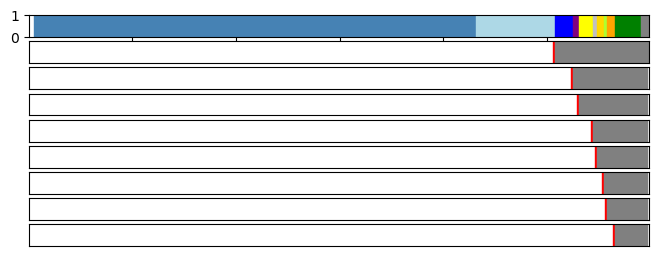

In [4]:
from matplotlib import pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import Rectangle

plt.figure(figsize=(8, 3))
start=1
end=29903

ax=plt.subplot(9,1,1)
ax.add_patch(Rectangle((266, 0), 21291, 10, color='steelblue')) #1ab
ax.add_patch(Rectangle((21563, 0), 3822, 10, color='lightblue')) #s
ax.add_patch(Rectangle((25393, 0), 828, 10, color='blue')) #3a
ax.add_patch(Rectangle((26245, 0), 228, 10, color='purple')) #E
ax.add_patch(Rectangle((26523, 0), 669, 10, color='yellow')) #M
ax.add_patch(Rectangle((27202, 0), 186, 10, color='silver')) #6
ax.add_patch(Rectangle((27394, 0), 366, 10, color='gold')) #orf7a
ax.add_patch(Rectangle((27756, 0), 132, 10, color='greenyellow')) #orf7b
ax.add_patch(Rectangle((27894, 0), 366, 10, color='orange')) #orf8
ax.add_patch(Rectangle((28274, 0), 1260, 10, color='green')) #N
ax.add_patch(Rectangle((29533, 0), 368, 10, color='gray')) #UTR
plt.xlim(start, 29900)

ax=plt.subplot(9,1,2)#3
ax.add_patch(Rectangle((25393-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((25393, 0), 4534-79, 5, color='gray'))
plt.xlim(start, 29900)
ax.set_xticks([])
ax.set_yticks([])

ax=plt.subplot(9,1,3)#E
ax.add_patch(Rectangle((26245-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((26245, 0), 3678-79, 5, color='gray'))
plt.xlim(start, end)
ax.set_xticks([])
ax.set_yticks([])

ax=plt.subplot(9,1,4)#M
ax.add_patch(Rectangle((26523-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((26523, 0), 3400-79, 5, color='gray'))
plt.xlim(start, end)
ax.set_xticks([])
ax.set_yticks([])

ax=plt.subplot(9,1,5)#6
ax.add_patch(Rectangle((27202-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((27202, 0), 2721-79, 5, color='gray'))
plt.xlim(start, end)
ax.set_xticks([])
ax.set_yticks([])


ax=plt.subplot(9,1,6)#7a
ax.add_patch(Rectangle((27394-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((27394, 0), 2529-79, 5, color='gray'))
plt.xlim(start, end)
ax.set_xticks([])
ax.set_yticks([])

ax=plt.subplot(9,1,7)#7b
ax.add_patch(Rectangle((27756-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((27756, 0), 2167-79, 5, color='gray'))
plt.xlim(start, end)
ax.set_xticks([])
ax.set_yticks([])

ax=plt.subplot(9,1,8)#8
ax.add_patch(Rectangle((27894-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((27894, 0), 2029-79, 5, color='gray'))
plt.xlim(start, end)
ax.set_xticks([])
ax.set_yticks([])

ax=plt.subplot(9,1,9)#N
ax.add_patch(Rectangle((28274-79, 0), 79, 5, color='red'))
ax.add_patch(Rectangle((28274, 0), 1574, 5, color='gray'))
plt.xlim(start, end)
ax.set_xticks([])
ax.set_yticks([])
plt.show()

#plt.savefig("/data1/huangyong/Project/Nanopore/SARS/示意图all.pdf")
#plt.close()

1,78
78,1262
1341,308


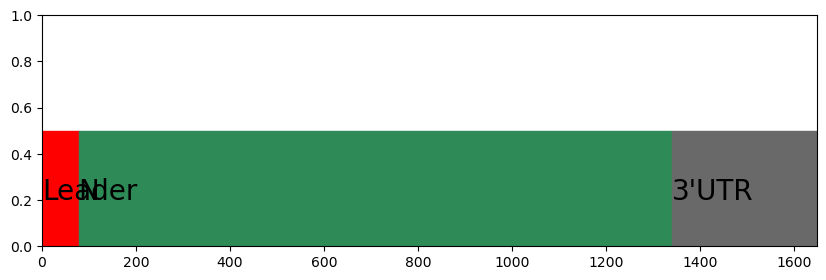

In [42]:
figure,ax2=plt.subplots(figsize=(10,3))

thickness = 0.5
ax2.add_patch(Rectangle((0, 0), 1649, 0.2, color='k'))
annotations = {"Leader":[1,79,0,"#FF0000"],"N":[78,1340,0,"#2E8B57"],"3'UTR":[1341,1649,0,"#696969"]}
for annot in annotations.values():
    ax2.add_patch( Rectangle((annot[0],0), annot[1]-annot[0], thickness,fill=bool, color=annot[3]))
    ax2.text(annot[0],0.2,list(annotations.keys())[list(annotations.values()).index(annot)],fontsize=20)
    print(f"{annot[0]},{annot[1]-annot[0]}")
ax2.set_xlim(0,1649)
plt.show()
#plt.savefig("/data1/huangyong/Project/Nanopore/SARS/Mod/N.Rectangle.pdf")
#plt.close()